In [1]:
library(tidyverse)
require(forcats)
library(RColorBrewer)
library(pheatmap)
library(qvalue)
library(viridis)
library(dendsort)
sort_hclust <- function(...) as.hclust(dendsort(as.dendrogram(...)))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite



In [2]:
traits<-c(
"Arvanitis.NatCommun.2019.Heart_Failure",
"Astle.Cell.2016.Basophil_count",
"Astle.Cell.2016.Eosinophil_count",
"Astle.Cell.2016.Lymphocyte_count",
"Astle.Cell.2016.Monocyte_count",
"Astle.Cell.2016.Neutrophil_count",
"Aylward.2018.biorxiv.Type_1_Diabetes",
"Barban.NatGenet.2016.Age_First_Birth",
"Barban.NatGenet.2016.Number_Children_Born",
"Bentham.NatGenet.2015.Lupus",
"Bentham.NatGenet.2015.Systemic_lupus_erythematosus",
"Bronson.NatGenet.2016.IgA_deficiency",
"Chiou.Nature.2021.Type_1_diabetes",
"Cordell.NatCommun.2015.Primary_Biliary_Cirrhosis",
"Deary.MolPsychiatry.2017.Tiredness",
"deLange.NatGenet.2017.Crohns_Disease",
"deLange.NatGenet.2017.Inflammatory_Bowel_Disease",
"deLange.NatGenet.2017.Ulcerative_Colitis",
"Demenais.NatGenet.2018.Asthma",
"Demontis.NatGenet.2019.Attention_Deficit_Hyperactivity_Disorder",
"denHoed.NatGenet.2013.Heart_Rate",
"Dubois.NatGenet.2010.Celiacs_Disease",
"Duncan.AmJPsychiatry.2017.Anorexia_Nervosa",
"Dupuis.NatGenet.2010.HOMA-B",
"Dupuis.NatGenet.2010.HOMA-IR",
"EAGLE.AmJMedGenet.2016.Childhood_Aggression",
"EAGLE.NatGenet.2015.Atopic_Dermatitis",
"Felix.HumMolGenet.2015.Childhood_BMI",
"Ferreira.2019.AJHG.Asthma_child_onset",
"Ferreira.NatGenet.2017.Allergy",
"GLGC.NatGenet.2013.HDL_Cholesterol",
"GLGC.NatGenet.2013.LDL_Cholesterol",
"GLGC.NatGenet.2013.Total_Cholesterol",
"GLGC.NatGenet.2013.Triglycerides",
"Grove.NatGenet.2019.Autism_Spectrum_Disorder",
"Hammerschlag.NatGenet.2017.Insomnia",
"Hoffmann.NatGenet.2018.HDL_cholesterol",
"Hoffmann.NatGenet.2018.LDL_cholesterol",
"Hoffmann.NatGenet.2018.Total_cholesterol",
"Hoffmann.NatGenet.2018.Triglycerides",
"Horikoshi.Nature.2016.Birth_Weight",
"Hou.HumMolGenet.2016.Bipolar_Disorder",
"IMSGC.NatGenet.2011.Multiple_Sclerosis",
"IMSGC.Science.2019.Multiple_sclerosis",
"Jansen.2019.NatGenet.Insomnia",
"Jansen.NatGenet.2019.Alzheimers_disease",
"Jiang.NatGenet.2018.Vitamin_D",
"Ji.NatGenet.2017.Primary_Sclerosing_Cholangitis",
"Jin.NatGenet.2016.Autoimmune_vitiligo",
"Jin.NatGenet.2016.Vitiligo",
"Jones.PLOSGen.2016.Chronotype",
"Jones.PLOSGen.2016.Sleep_Duration",
"Kemp.NatGenet.2017.Heel_bone_mineral_density",
"Kilpelainen.NatCommun.2016.Leptin",
"Lambert.NatGenet.2013.Alzheimers_Disease",
"Locke.Nature.2015.BMI",
"Luciano.NatGenet.2017.Neuroticism",
"Mahajan.NatGenet.2018.Type_2_Diabetes",
"Malik.2018.NatGenet.Stroke",
"Manning.NatGenet.2012.Fasting_Glucose_adj_BMI",
"Manning.NatGenet.2012.Fasting_Glucose",
"Manning.NatGenet.2012.Fasting_Insulin_adj_BMI",
"Manning.NatGenet.2012.Fasting_Insulin",
"Marinelli.Sleep.2016.Child_Sleep_Duration",
"Michailidou.Nature.2017.Breast_cancer",
"Nalls.LancetNeurol.2019.Parkinsons_disease",
"Namjou.BMCMed.2019.Nonalcoholic_fatty_liver_disease",
"Nelson.NatGenet.2017.Coronary_Artery_Disease",
"Nielson.2018.NatGenet.Atrial_Fibrillation",
"Okada.Nature.2014.Rheumatoid_Arthritis",
"Okbay.Nature.2016.Educational_Attainment",
"Palmer.MolPsych.2021.problematic_opioid_use",
"Pattaro.NatCommun.2016.Chronic_Kidney_Disease",
"PGC.MolPsychiatry.2017.Obsessive_Compulsive_Disorder",
"PGC.MolPsychiatry.2017.Post_Traumatic_Stress_Disorder",
"PGC.Nature.2014.Schizophrenia",
"ReproGen.NatGenet.2015.Age_At_Menopause",
"ReproGen.NatGenet.2017.Age_At_Menarche",
"SAIGE.UKBB.2018.Tobacco_use_disorder",
"Sakornsakolpat.NatGenet.2019.Chronic_obstructive_pulmonary_disease",
"Savage.NatGenet.2018.Intelligence",
"Saxena.NatGenet.2010.2hr_Glucose_adjBMI",
"Schafmayer.Gut.2019.Diverticular_disease",
"Schumann.PNAS.2016.Alcohol_Usage",
"Shadrina.PLoSGenet.2019.Varicose_veins",
"Shrine.NatGenet.2019.FEV1_FVC_ratio",
"Shrine.NatGenet.2019.Forced_expiration_volume",
"Shrine.NatGenet.2019.Forced_vital_capacity",
"Shrine.NatGenet.2019.Peak_expiratory_flow",
"Sniekers.NatGenet.2017.Intelligence",
"Stahl.2018.biorxiv.Bipolar_Disorder",
"Strawbridge.Diabetes.2011.Fasting_ProInsulin",
"Taal.NatGenet.2012.Head_Circumference",
"Tachmazidou.NatGenet.2019.Osteoarthritis",
"Teumer.Diabetes.2016.Microalbuminuria",
"Teumer.NatCommun.2018.Thyroid_stimulating_hormone",
"Tin.NatGenet.2019.Gout",
"Tin.NatGenet.2019.Serum_urate",
"UKB.Neale_v2.2018.Body_mass_index",
"UKB.Neale_v2.2018.Standing_height",
"UKB.Neale_v2.2018.Vitamin_D",
"vandenBerg.BehavGenet.2016.Extraversion",
"vanderValk.HumMolGenet.2014.Birth_Length",
"vanRheenen.NatGenet.2016.Amyotrophic_Lateral_Sclerosis",
"Watanabe.NatGenet.2019.Diastolic_blood_pressure",
"Watanabe.NatGenet.2019.Pulse_rate",
"Watanabe.NatGenet.2019.Systolic_blood_pressure",
"Watson.2018.NatGenet.Anorexia_Nervosa",
"Wheeler.PlosMed.2017.HbA1c",
"Wiberg.NatCommun.2019.Carpal_tunnel_syndrome",
"Wray.biorxiv.2018.Major_Depressive_Disorder",
"Wuttke.NatGenet.2019.Blood_urea_nitrogen",
"Wuttke.NatGenet.2019.Chronic_kidney_disease",
"Wuttke.NatGenet.2019.eGFR",
"Wuttke.NatGenet.2019.Serum_creatinine",
"Yengo.biorxiv.2018.BMI",
"Yengo.biorxiv.2018.Height",
"Zhu.RespirRes.2019.Hypertension",
###
"Eijsbouts.NatGenet.2021.Irritable_bowel_syndrome",
"Fairfield.Hepatology.2021.Gallstones",
"Harris.SciRep.2024.Colorectal_cancer",
"He.NatGenet.2023.Peptic_ulcer_disease",
"Jiang.NatGenet.2021.Chest_pain",
"Jiang.NatGenet.2021.Diarrhea",
"Jiang.NatGenet.2021.Dyspepsia",
"Ong.Gut.2022.GERD",
"Verma.Science.2024.Cholecystitis",
"Zhou.CellGenom.2022.Acute_appendicitis",
"Zhou.NatGenet.2018.Appendicitis"

)


In [3]:
dat_all <- read_tsv("./atac_gwas/res.summary.tsv", col_names = c("Cluster", "Coefficient", "Coefficient_std_error", "Coefficient_P_value", "Trait", "Set"))
results <- dat_all 
colnames(results) <- c( "Cluster", "Coefficient", "Coefficient_std_error", "Coefficient_P_value", "Trait", "Set")


Rows: 516 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Cluster, Trait, Set
dbl (3): Coefficient, Coefficient_std_error, Coefficient_P_value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
head(results)


Cluster,Coefficient,Coefficient_std_error,Coefficient_P_value,Trait,Set
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Goblet,2.715589e-08,1.046230e-08,0.004721355,Arvanitis.NatCommun.2019.Heart_Failure,merged
Enterocytes,8.146214e-09,1.258536e-08,0.258726363,Arvanitis.NatCommun.2019.Heart_Failure,merged
EECs,2.656226e-09,1.186331e-08,0.411416501,Arvanitis.NatCommun.2019.Heart_Failure,merged
SCs,-1.536945e-08,1.014761e-08,0.935061565,Arvanitis.NatCommun.2019.Heart_Failure,merged
Goblet,1.230182e-07,7.150789e-08,0.042684870,Astle.Cell.2016.Basophil_count,merged
SCs,6.479757e-08,5.653418e-08,0.125863169,Astle.Cell.2016.Basophil_count,merged


Warning message:
“Setting row names on a tibble is deprecated.”


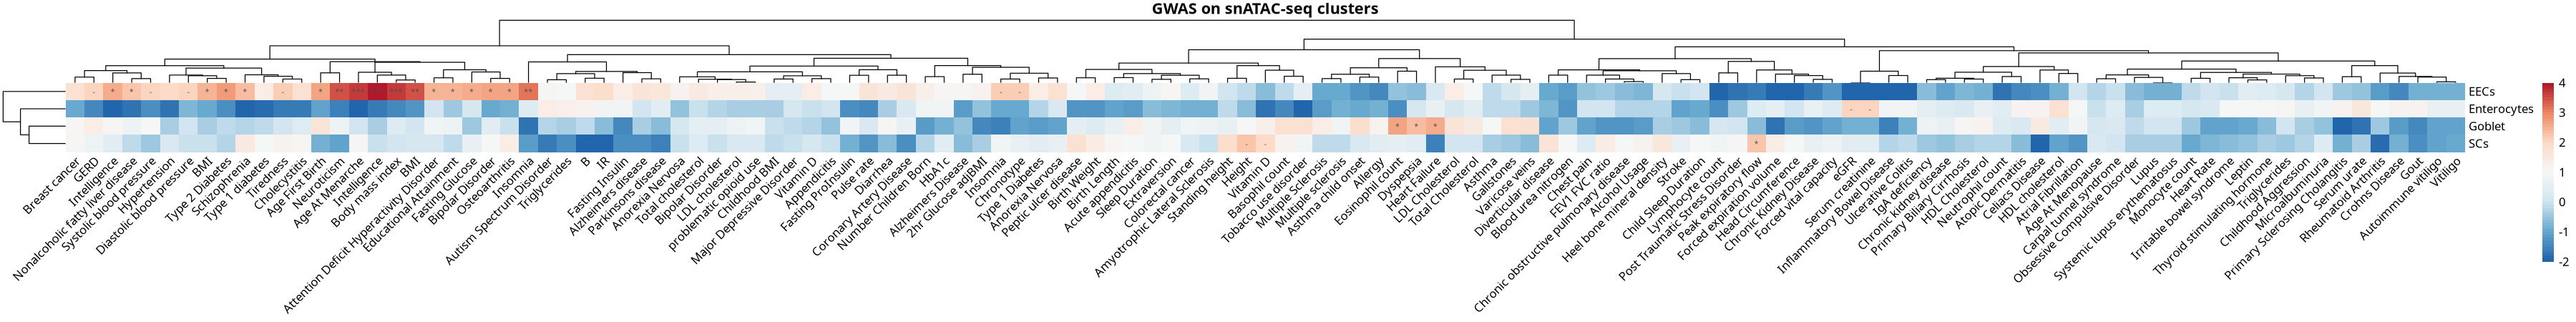

In [5]:
cls <- results %>%
  filter(Coefficient_P_value < 0.05 & Trait %in% traits) %>%
  select(Cluster) %>%
  distinct() %>%
  pull()

cluster_traits <- results %>%
  filter(Trait %in% traits & Cluster %in% cls) %>%
  group_by(Trait) %>%
  mutate(FDR = p.adjust(Coefficient_P_value, method = "fdr")) %>%
  ungroup() %>%
  arrange(FDR)

mat <- results %>%
  filter(Cluster %in% cls & Trait %in% traits) %>%
  # mutate(enrich = -log10(Coefficient_P_value)) %>%
  mutate(enrich = Coefficient / Coefficient_std_error) %>%
  select(Cluster, Trait, enrich) %>%
  filter(!grepl("adj_BMI", Trait)) %>%
  spread(Trait, enrich)

mat <- data.frame(mat)

rownames(mat) <- mat$Cluster
colnames(mat) <- gsub(".*[.]", "", gsub("UKBB_", "", colnames(mat)))

mat$Cluster <- NULL

mat_p <- cluster_traits %>%
  filter(Cluster %in% cls & Trait %in% traits) %>%
  mutate(enrich = FDR) %>%
  select(Cluster, Trait, enrich) %>%
  filter(!grepl("adj_BMI", Trait)) %>%
  spread(Trait, enrich)

rownames(mat_p) <- mat_p$Cluster
colnames(mat_p) <- gsub(".*[.]", "", gsub("UKBB_", "", colnames(mat_p)))
mat_p <- data.frame(mat_p)
mat_p$Cluster <- NULL

anno <- matrix("", nrow = nrow(mat), ncol = ncol(mat))
colnames(anno) <- colnames(mat)
rownames(anno) <- rownames(mat)
anno[mat_p<0.1] <- "-"
anno[mat_p<0.05] <- "*"
anno[mat_p<0.01] <- "**"
anno[mat_p<0.001] <- "***"

upper=4
lower=-2
n_cols = (upper-lower)*10

# mat[mat>upper]<-upper
# mat[mat<lower]<-lower

hclust_method="ward.D2"
hclust_rows <- sort_hclust(hclust(dist(mat), method = hclust_method))
hclust_cols <- sort_hclust(hclust(dist(t(mat)),method = hclust_method))

options(repr.plot.width=30, repr.plot.height=3.75)
pheatmap(mat,
         color = colorRampPalette(rev(brewer.pal(n = 7, name = "RdBu")))(n_cols),
         breaks = seq(lower, upper, 0.1),
         fontsize_row = 10,
         fontsize_col = 10,
         display_numbers = anno,
         fontsize_number = 6,
         labels_col = gsub("_", " ", colnames(mat)),
         labels_row = rownames(mat),
#         annotation_row = row_label,
#         annotation_colors = ann_colors,
         # cluster_cols = hclust_cols,
         # cluster_rows = hclust_rows,
         angle_col = 45,
         main = "GWAS on snATAC-seq clusters",
         # labels_row = labels[match(gsub("cluster_", "", rownames(mat)), labels$clu), ] %>% pull(name),
         )


In [6]:
head(mat_p)
head(mat)


,Heart_Failure,Basophil_count,Eosinophil_count,Lymphocyte_count,Monocyte_count,Neutrophil_count,Type_1_Diabetes,Age_First_Birth,Number_Children_Born,Lupus,⋯,Major_Depressive_Disorder,Blood_urea_nitrogen,Chronic_kidney_disease,eGFR,Serum_creatinine,BMI.1,Height,Acute_appendicitis,Appendicitis,Hypertension
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.54855533,0.7463505,0.9106795,0.9974107,0.8160006,0.9571552,0.3541758,0.01699389,0.3843714,0.7951216,⋯,0.5682046,0.8936609,0.8420967,0.99870557,0.99870557,0.001172051,0.72725877,0.4326365,0.6600572,0.1147753
2,0.51745273,0.9287368,0.9106795,0.9974107,0.8160006,0.6966042,0.7880951,0.84889081,0.3843714,0.7951216,⋯,0.5682046,0.8936609,0.7104597,0.09058518,0.09058518,0.897439250,0.72725877,0.8675533,0.7092600,0.9569087
3,0.01888542,0.1707395,0.0142388,0.8681826,0.8160006,0.6966042,0.8784214,0.10280555,0.8841307,0.7951216,⋯,0.5682046,0.8936609,0.7104597,0.99870557,0.99870557,0.624671642,0.35819287,0.3346961,0.7137427,0.8405383
4,0.93506156,0.2517263,0.6033111,0.7532396,0.8160006,0.8107760,0.6282178,0.84889081,0.8116985,0.7951216,⋯,0.5682046,0.6535017,0.8420967,0.66731737,0.66731737,0.624671642,0.05489707,0.3346961,0.7092600,0.8172155


,Heart_Failure,Basophil_count,Eosinophil_count,Lymphocyte_count,Monocyte_count,Neutrophil_count,Type_1_Diabetes,Age_First_Birth,Number_Children_Born,Lupus,⋯,Major_Depressive_Disorder,Blood_urea_nitrogen,Chronic_kidney_disease,eGFR,Serum_creatinine,BMI,Height,Acute_appendicitis,Appendicitis,Hypertension
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EECs,0.2239027,-0.150368,-0.5511176,-2.7957049,-0.1462528,-1.7185866,1.3497759,2.631658,1.2030439,-0.82432161,⋯,0.55469210,-1.1401510,-1.0031124,-3.0127575,-3.0127575,3.43800096,-0.1519692,0.4552147,0.97405631,1.9003467
Enterocytes,0.6472769,-1.466448,-1.3449511,-1.3669634,0.1266427,0.4798517,-0.2303017,-1.031688,0.8698700,0.35033198,⋯,0.12527367,-1.2462346,0.3712387,2.0019270,2.0019270,-1.26709451,-0.6045434,-1.1148999,0.06317678,-1.7158881
Goblet,2.5955957,1.720345,2.6912071,0.1659674,-0.4898498,0.3899085,-1.1671315,1.631402,-1.1958924,0.08354385,⋯,-0.17180512,-0.4221944,0.6850451,-0.8211450,-0.8211450,0.07903163,0.9188140,1.3547951,-0.56435210,-0.3329229
SCs,-1.5145876,1.146166,0.5196450,0.8841416,-0.9002283,-0.2743236,0.4842368,-0.894879,-0.2761248,-0.32001466,⋯,-0.04735561,0.9806794,-0.5595163,0.4298327,0.4298327,0.17172581,2.2050792,0.9646979,-0.08016004,0.2311279
